# LR 8

## Упражнения

### Упражнение № 1
Это упражнение относится к [Примеру 1](#example-1-static-one-dimensional-data).
1. Выберите значение для оценочной дисперсии модели `Q_est`, которое больше оценочной дисперсии измерения `R_est`.
2. Повторите анализ Примера 1 для этого нового значения.
3. Сходится ли оценка KF?
4. Почему изменились оценки? Они выглядят более шумными, чем раньше? Почему?

### Упражнение №2

Это упражнение относится к [Примеру 2](#example-2-dynamic-one-dimensional-data).

В случае, который мы рассмотрели выше, оценка KF была близка к измерениям, и оба отличались от истинного значения.
Изменяйте параметры алгоритма, пока не найдете некоторые комбинации, которые достигают следующего:

1. Измерения, оценка KF и истинное значение все близки.
2. Измерения, оценка KF и истинное значение все заметно отличаются.
3. Измерения близки к истинному значению, но оценка KF отличается.

Обсудите свои выводы.

### Упражнение №3

Это упражнение относится к [Примеру 3](#example-3-dynamic-two-dimensional-data).

В исходном примере мы использовали и Положение, и Скорость (модель PV) в векторе состояния, т. е. $\boldsymbol{x} = \begin{bmatrix} x & y & \dot x & \dot y \end{bmatrix}^T$.

Что произойдет, если мы используем только Положение (модель P) для описания состояния? В конце концов, наши измерения предоставляют только положение. Действительно ли нам нужно включать скорость?

1. Перепишите алгоритм выше для модели P.

**💡 Подсказка:** каков размер вектора состояния в этом случае? Каковы размерности матриц, характеризующих систему?

# ______________________________________________________________________

#### Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
np.random.seed(0)  # для воспроизводимости

#### Упражнение 1

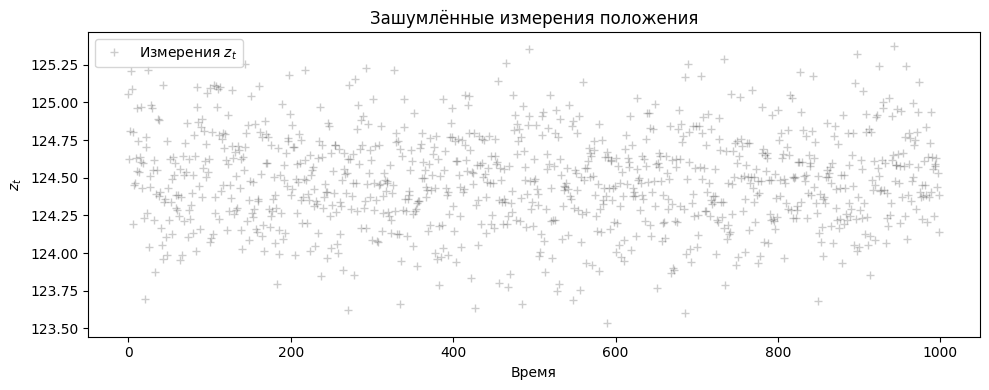

In [2]:
mu = 124.5  # истинное положение
R = 0.1     # фактическое СКО измерений

n_measurements = 1000
Z = np.random.normal(mu, np.sqrt(R), size=n_measurements)

plt.figure(figsize=(10, 4))
plt.plot(Z, 'k+', label='Измерения $z_t$', alpha=0.2)
plt.title('Зашумлённые измерения положения')
plt.xlabel('Время')
plt.ylabel('$z_t$')
plt.legend()
plt.tight_layout()
plt.show()

видно, что шум носит белый характер, точки равномерно рассеяны вокруг центра, шум относительно мал. измерения лежат приблизительно в диапазоне 123.5-125.3, то есть отклоняются от истинного положения mu = 124.5

In [3]:
def kalman_1d(x, P, measurement, R_est, Q_est):
    # Прогноз
    x_pred = x
    P_pred = P + Q_est
    # Коррекция
    K = P_pred / (P_pred + R_est)
    x_est = x_pred + K * (measurement - x_pred)
    P_est = (1 - K) * P_pred
    return x_est, P_est


def plot_1d_comparison(measurements_made, estimate, true_value, axis):
    axis.plot(measurements_made, 'k+', label='Измерения', alpha=0.3)
    axis.plot(estimate, '-', label='Оценка КФ')
    if not isinstance(true_value, (list, tuple, np.ndarray)):
        axis.axhline(true_value, color='r', label='Истинное значение', alpha=0.5)
    else:
        axis.plot(true_value, color='r', label='Истинное значение', alpha=0.5)
    axis.legend(loc='lower right')
    axis.set_title('Оценка положения / шаг времени')
    axis.set_xlabel('Время')
    axis.set_ylabel('$x_t$')


def plot_1d_error(estimated_error, lower_limit, upper_limit, axis):
    axis.plot(estimated_error, label='Оценка дисперсии $P$')
    axis.legend(loc='upper right')
    axis.set_title('Оценка ошибки / шаг времени')
    axis.set_xlabel('Время')
    axis.set_ylabel('$P_t$')
    plt.setp(axis, 'ylim', [lower_limit, upper_limit])

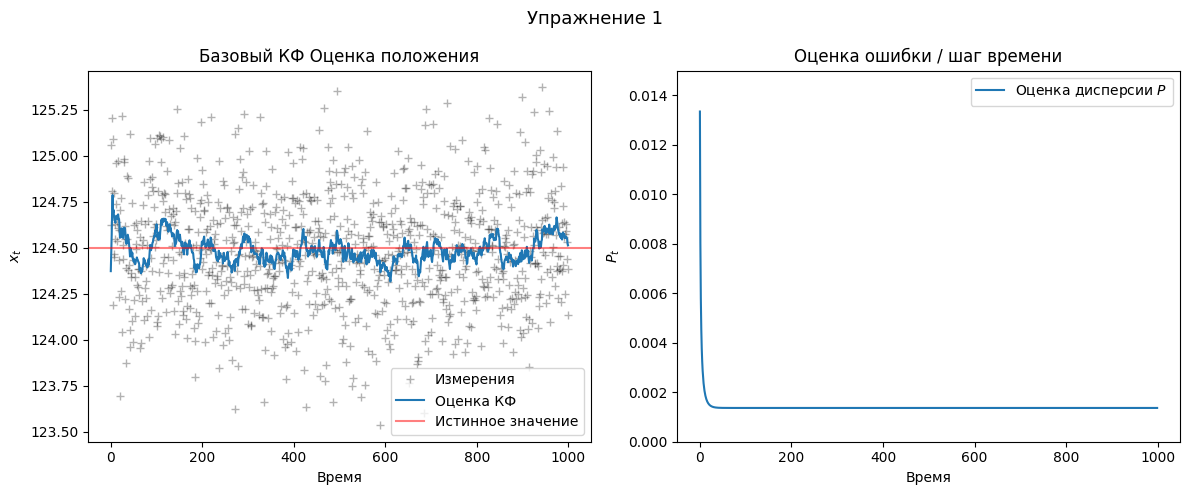

Финальная оценка КФ: 124.5138 | Истинное значение: 124.5


In [4]:
Q_est_base = 1e-4
R_est_base = 2e-2

x = 123
P = 0.04
KF_estimate_base = []
KF_error_base = []

for z in Z:
    x, P = kalman_1d(x, P, z, R_est_base, Q_est_base)
    KF_estimate_base.append(x)
    KF_error_base.append(P)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_1d_comparison(Z, KF_estimate_base, mu, axes[0])
axes[0].set_title('Базовый КФ Оценка положения')
plot_1d_error(KF_error_base, 0, 0.015, axes[1])
plt.suptitle('Упражнение 1', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Финальная оценка КФ: {KF_estimate_base[-1]:.4f} | Истинное значение: {mu}")

фильтр сошёлся очень быстро, уже в первые <100 шагов оценка вышла на уровень истинного значения 124.5.Ф инальная оценка 124.5138 отличается от истинного значения 124.5 всего на 0.0138 (погрешность менее 0.01%). Оценка КФ умеренно шумит, синяя линия колеблется вокруг красной с амплитудой

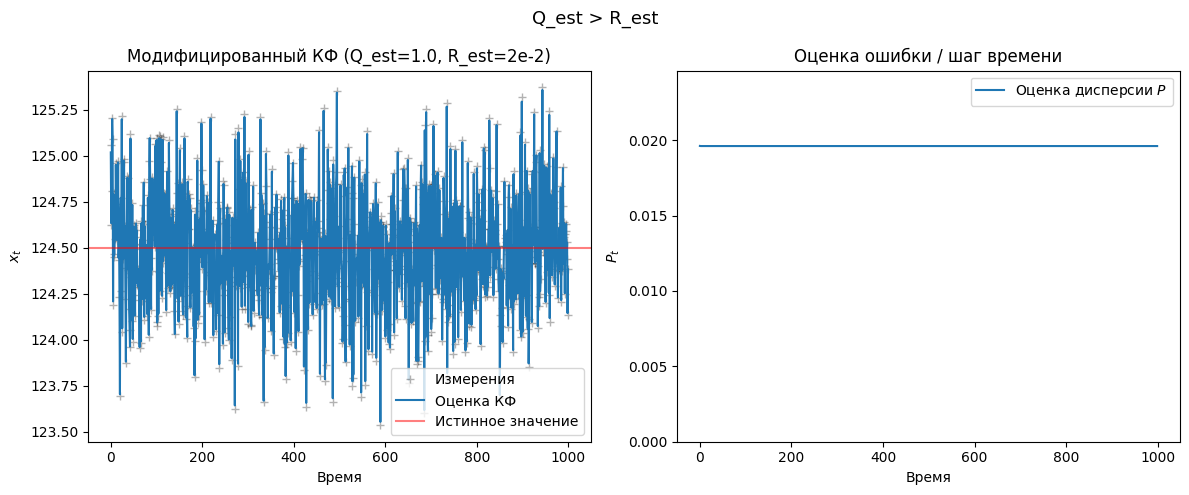

Финальная оценка КФ: 124.3821 | Истинное значение: 124.5


In [6]:
Q_est_mod = 1.0   # Q_est БОЛЬШЕ R_est
R_est_mod = 2e-2  # R_est остаётся прежним

x = 123
P = 0.04
KF_estimate_mod = []
KF_error_mod = []

for z in Z:
    x, P = kalman_1d(x, P, z, R_est_mod, Q_est_mod)
    KF_estimate_mod.append(x)
    KF_error_mod.append(P)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_1d_comparison(Z, KF_estimate_mod, mu, axes[0])
axes[0].set_title('Модифицированный КФ (Q_est=1.0, R_est=2e-2)')
plot_1d_error(KF_error_mod, 0, max(KF_error_mod) + 0.005, axes[1])
plt.suptitle('Q_est > R_est', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Финальная оценка КФ: {KF_estimate_mod[-1]:.4f} | Истинное значение: {mu}")

Фильтр формально сходится, однако оценка остаётся хаотичной на протяжении всех 1000 шагов. Финальная оценка 124.3821 отличается от истинного значения на 0.1179, это не систематическая ошибка, и в другом запуске результат мог бы оказаться ближе к 124.5. Оценка очень сильно шумит, синяя линия практически повторяет каждое отдельное измерение. Правый график объясняет почему: дисперсия P зафиксировалась на уровне около 0.020 с первого же шага и не снижается. При большом Q_est фильтр постоянно думает, что модель ненадёжна, и на каждом шаге почти полностью доверяет текущему измерению, не накапливает знания о системе

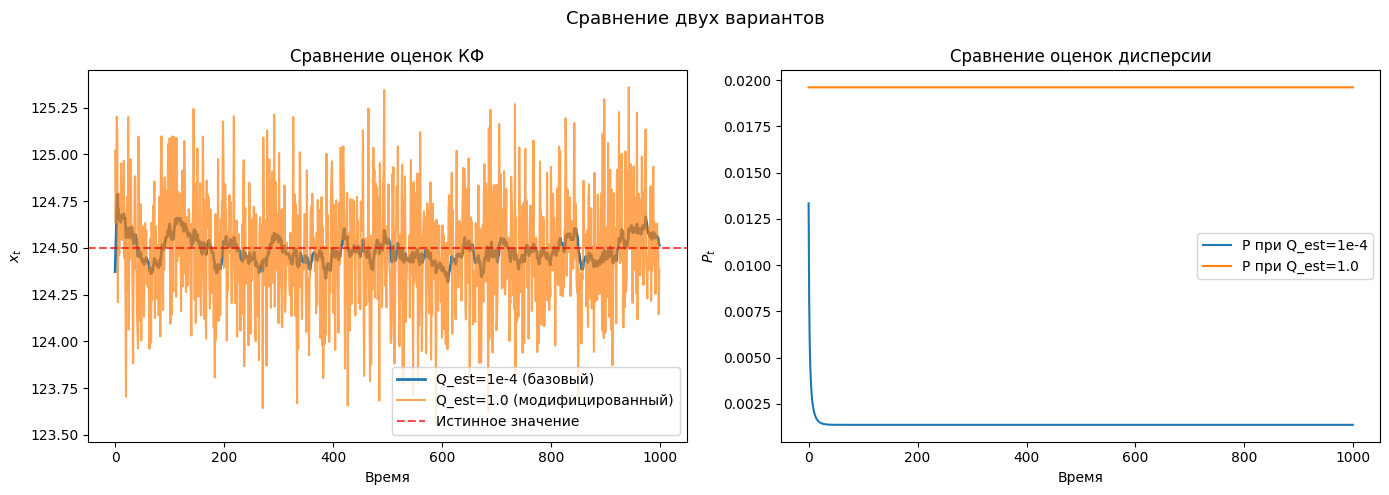

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(KF_estimate_base, label='Q_est=1e-4 (базовый)', linewidth=2)
axes[0].plot(KF_estimate_mod, label='Q_est=1.0 (модифицированный)', alpha=0.7)
axes[0].axhline(mu, color='r', linestyle='--', label='Истинное значение', alpha=0.7)
axes[0].set_title('Сравнение оценок КФ')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('$x_t$')
axes[0].legend()

axes[1].plot(KF_error_base, label='P при Q_est=1e-4')
axes[1].plot(KF_error_mod, label='P при Q_est=1.0')
axes[1].set_title('Сравнение оценок дисперсии')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('$P_t$')
axes[1].legend()

plt.suptitle('Сравнение двух вариантов', fontsize=13)
plt.tight_layout()
plt.show()

При Q_est = 1.0 оценка значительно более шумная. Q_est отражает то, насколько сильно фильтр не доверяет своей модели. При большом Q_est дисперсия P не снижается, усиление K остаётся высоким, и фильтр на каждом шаге сильно сдвигает оценку в сторону текущего измерения. Оба варианта находят правильное среднее, но только малое Q_est даёт действительно полезную фильтрацию

### Упражнение 2

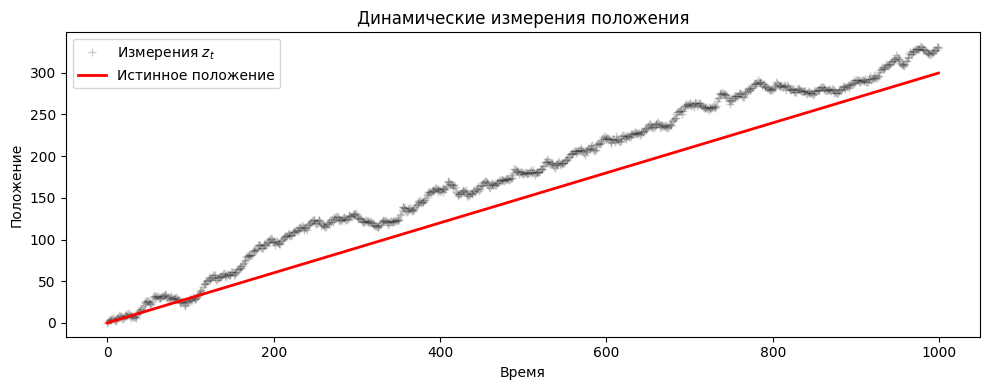

In [8]:
v0 = 0.3
x0 = 0.0
R_dyn = 4.0

n_measurements = 1000
Zv = np.zeros(n_measurements)
Zx = np.zeros(n_measurements)
for t in range(0, n_measurements - 1):
    Zv[t] = np.random.normal(v0, np.sqrt(R_dyn))
    Zx[t + 1] = Zx[t] + Zv[t] * 1

Xt = np.array([x0 + v0 * t for t in range(n_measurements)])

plt.figure(figsize=(10, 4))
plt.plot(Zx, 'k+', label='Измерения $z_t$', alpha=0.2)
plt.plot(Xt, 'r-', label='Истинное положение', linewidth=2)
plt.title('Динамические измерения положения')
plt.xlabel('Время')
plt.ylabel('Положение')
plt.legend()
plt.tight_layout()
plt.show()

На графике измерения (серые крестики) систематически идут выше истинной траектории (красная линия), особенно в средней части

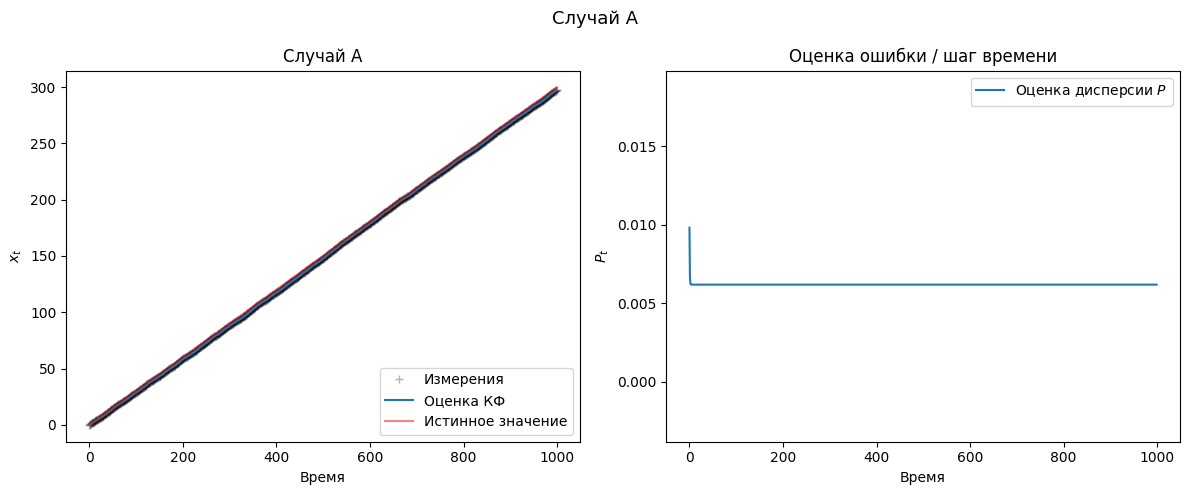

In [10]:
# Генерируем данные с малым шумом для случая A
R_small = 0.01
Zv_A = np.zeros(n_measurements)
Zx_A = np.zeros(n_measurements)
for t in range(n_measurements - 1):
    Zv_A[t] = np.random.normal(v0, np.sqrt(R_small))
    Zx_A[t + 1] = Zx_A[t] + Zv_A[t]

x, P = 0, 0.5
Q_A, R_A = 0.01, 0.01
KF_est_A, KF_err_A = [], []
for z in Zx_A:
    x, P = kalman_1d(x, P, z, R_A, Q_A)
    KF_est_A.append(x)
    KF_err_A.append(P)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_1d_comparison(Zx_A, KF_est_A, Xt, axes[0])
axes[0].set_title('Случай A')
plot_1d_error(KF_err_A, min(KF_err_A) - 0.01, max(KF_err_A) + 0.01, axes[1])
plt.suptitle('Случай A', fontsize=13)
plt.tight_layout()
plt.show()

На левом графике все три линии практически сливаются в одну и неотличимы визуально на всём диапазоне

P быстро падает с 0.010 до около 0.006 и стабилизируется. Это говорит о том, что фильтр нашёл устойчивый баланс между моделью и измерениями и сохраняет его на протяжении всего времени

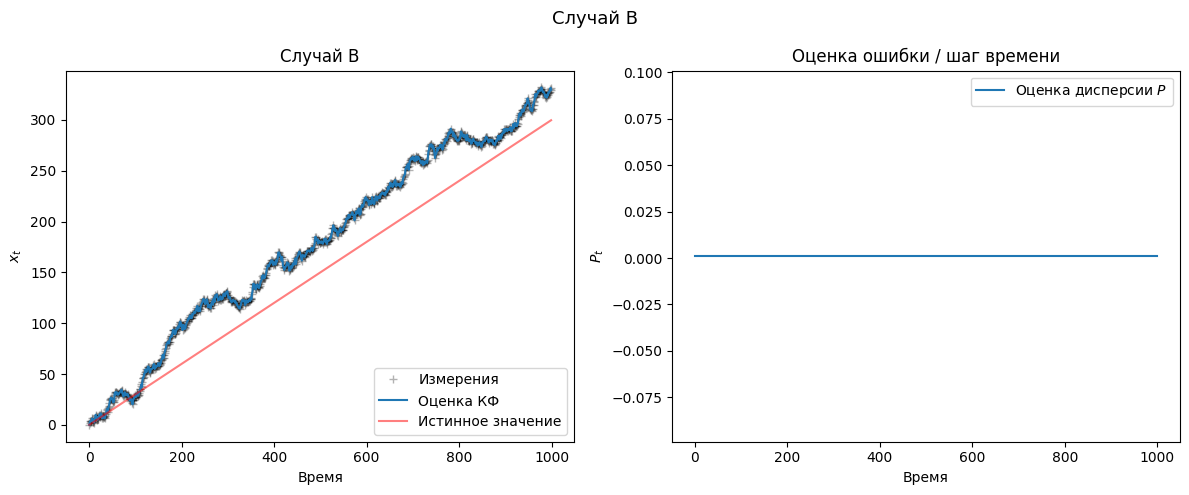

In [11]:
x, P = 0, 0.5
Q_B, R_B = 100.0, 0.001
KF_est_B, KF_err_B = [], []
for z in Zx:  # используем исходные данные с R=4.0
    x, P = kalman_1d(x, P, z, R_B, Q_B)
    KF_est_B.append(x)
    KF_err_B.append(P)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_est_B, Xt, axes[0])
axes[0].set_title('Случай B')
plot_1d_error(KF_err_B, min(KF_err_B) - 0.1, max(KF_err_B) + 0.1, axes[1])
plt.suptitle('Случай B', fontsize=13)
plt.tight_layout()
plt.show()

Оценка КФ (синяя) практически полностью сливается с измерениями (серые крестики, их практически не видно) и уходит выше истинного значения. Красная линия идёт заметно ниже, особенно во второй половине

P мгновенно падает до нуля и остаётся там. фильтр уверен в своей оценке (P=0), потому что доверяет только измерениям, но при этом сами измерения далеки от истины из-за накопленного шума скорости

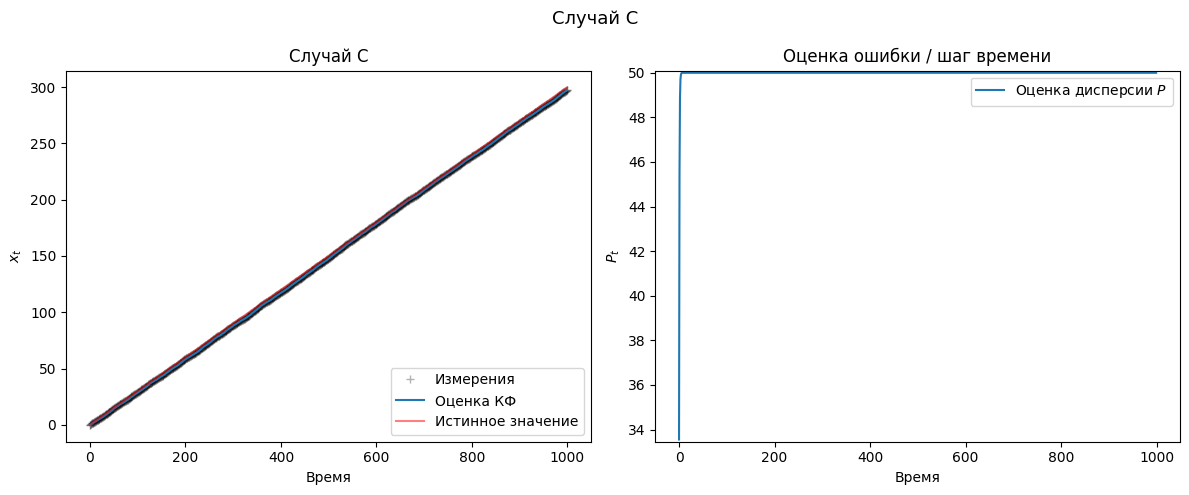

In [12]:
x, P = 0, 0.5
Q_C, R_C = 50.0, 100.0
KF_est_C, KF_err_C = [], []
for z in Zx_A:  # данные с малым шумом
    x, P = kalman_1d(x, P, z, R_C, Q_C)
    KF_est_C.append(x)
    KF_err_C.append(P)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_1d_comparison(Zx_A, KF_est_C, Xt, axes[0])
axes[0].set_title('Случай C')
plot_1d_error(KF_err_C, min(KF_err_C) - 0.1, max(KF_err_C) + 0.1, axes[1])
plt.suptitle('Случай C', fontsize=13)
plt.tight_layout()
plt.show()

И снова измерения сливаются с оценкой КФ с Истинным значением (обратное случаю В), оценка сразу же возрастает до 50 и удерживается до конца

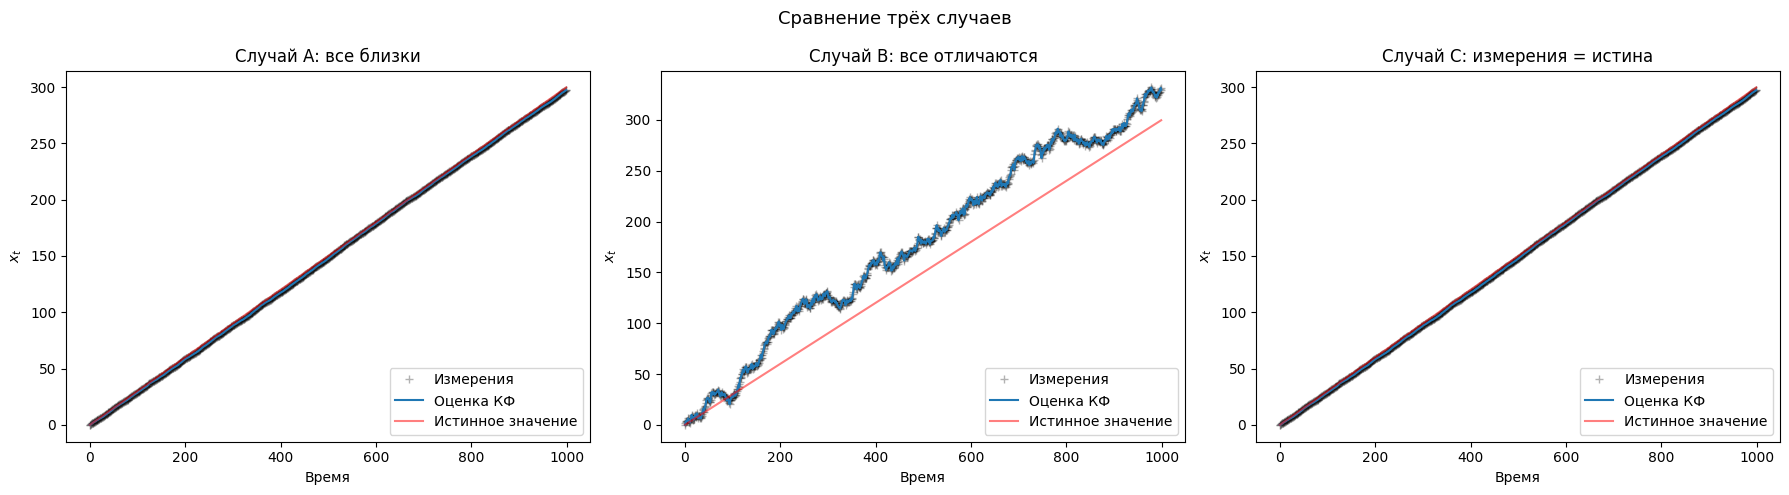

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, est, zdata, xt, title in zip(
    axes,
    [KF_est_A, KF_est_B, KF_est_C],
    [Zx_A, Zx, Zx_A],
    [Xt, Xt, Xt],
    ['Случай A: все близки', 'Случай B: все отличаются', 'Случай C: измерения = истина']
):
    plot_1d_comparison(zdata, est, xt, ax)
    ax.set_title(title)

plt.suptitle('Сравнение трёх случаев', fontsize=13)
plt.tight_layout()
plt.show()

важно не то, насколько велики Q и R, а то, насколько они соответствуют реальному источнику неопределённости

## Упражнение 3

In [16]:
xy_motion = pd.read_csv(
    'https://zenodo.org/records/10951538/files/kf_ts1.csv?download=1',
    header=None
).values.astype('float32')

kalman_PV = cv2.KalmanFilter(4, 2, 0)
q, r, dtime = 1, 20, 1

kalman_PV.measurementMatrix = np.array([[1,0,0,0],[0,1,0,0]], np.float32)
kalman_PV.transitionMatrix = np.array([
    [1,0,dtime,0],[0,1,0,dtime],[0,0,1,0],[0,0,0,1]
], np.float32)
kalman_PV.processNoiseCov = np.eye(4, dtype=np.float32) * q
kalman_PV.measurementNoiseCov = np.eye(2, dtype=np.float32) * r

KF_est_PV = []
for i in xy_motion:
    pred = kalman_PV.predict()
    kalman_PV.correct(i)
    KF_est_PV.append((pred[0][0], pred[1][0]))

print(f"Модель PV — количество оценок: {len(KF_est_PV)}")
print(f"Первые 5 оценок: {KF_est_PV[:5]}")

Модель PV — количество оценок: 205
Первые 5 оценок: [(np.float32(0.0), np.float32(0.0)), (np.float32(0.11190476), np.float32(0.06904762)), (np.float32(0.7039418), np.float32(0.36711615)), (np.float32(1.7040358), np.float32(1.3805363)), (np.float32(2.6022434), np.float32(3.239656))]


Траектория содержит 205 оценок, фильтр Калмана выполнил 205 шагов предсказания и коррекции. По первым 5 оценкам можно предположить, что объект начинает движение из состояния покоя и ускоряется

In [17]:
kalman_P = cv2.KalmanFilter(2, 2, 0)

kalman_P.measurementMatrix = np.array([[1,0],[0,1]], np.float32)
kalman_P.transitionMatrix  = np.array([[1,0],[0,1]], np.float32)
kalman_P.processNoiseCov   = np.eye(2, dtype=np.float32) * q
kalman_P.measurementNoiseCov = np.eye(2, dtype=np.float32) * r

KF_est_P = []
for i in xy_motion:
    pred = kalman_P.predict()
    kalman_P.correct(i)
    KF_est_P.append((pred[0][0], pred[1][0]))

print(f"количество оценок(модель р): {len(KF_est_P)}")

количество оценок(модель р): 205


используется матрица 2х2, такая простая модель работает для медленно движущихся или стационарных объектов

Сравнение моделей PV и P

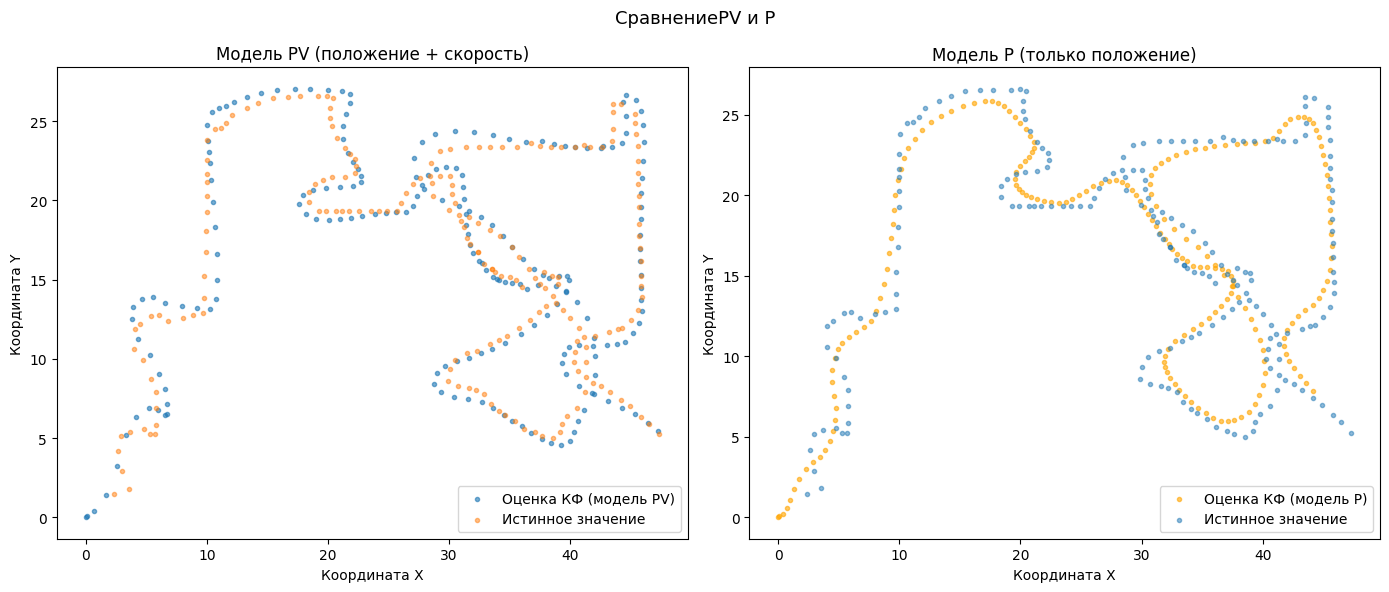

In [18]:
x_true, y_true = zip(*xy_motion)
x_PV, y_PV = zip(*KF_est_PV)
x_P,  y_P  = zip(*KF_est_P)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(x_PV, y_PV, marker='.', label='Оценка КФ (модель PV)', alpha=0.6)
axes[0].scatter(x_true, y_true, marker='.', label='Истинное значение', alpha=0.5)
axes[0].set_title('Модель PV (положение + скорость)')
axes[0].set_xlabel('Координата X')
axes[0].set_ylabel('Координата Y')
axes[0].legend()

axes[1].scatter(x_P, y_P, marker='.', label='Оценка КФ (модель P)', alpha=0.6, color='orange')
axes[1].scatter(x_true, y_true, marker='.', label='Истинное значение', alpha=0.5)
axes[1].set_title('Модель P (только положение)')
axes[1].set_xlabel('Координата X')
axes[1].set_ylabel('Координата Y')
axes[1].legend()

plt.suptitle('СравнениеPV и P', fontsize=13)
plt.tight_layout()
plt.show()

Модель PV, как будто бы, ближе находитсся к истинным значениям, в сравнении с моделью Р

In [19]:
from sklearn.metrics import mean_squared_error

mse_PV = mean_squared_error(
    np.array(list(zip(x_true, y_true))),
    np.array(list(zip(x_PV, y_PV)))
)
mse_P = mean_squared_error(
    np.array(list(zip(x_true, y_true))),
    np.array(list(zip(x_P, y_P)))
)

results_df = pd.DataFrame({
    'Модель': ['PV (положение + скорость)', 'P (только положение)'],
    'MSE': [round(mse_PV, 4), round(mse_P, 4)],
    'Вектор состояния': ['[x, y, ẋ, ẏ]', '[x, y]'],
    'Размерность A': ['4×4', '2×2']
})
print(results_df.to_string(index=False))

                   Модель    MSE Вектор состояния Размерность A
PV (положение + скорость) 0.6533     [x, y, ẋ, ẏ]           4×4
     P (только положение) 5.7957           [x, y]           2×2


PV выигрывает с MSE 0.6533 против 5.7957 у модели P, Разница в 9 раз в пользу PV